In this notebook I study the python implementation of SVD \
Later, I will implements analog in C++ for gamma spectrometry problem \
and need to have a solid (although slow) baseline to compare with

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mplimg
import math as m
import seaborn as sns

First, use SVD for dimensionality reduction. Load sample image

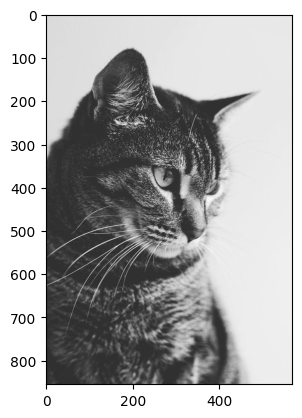

In [2]:
cat_arr = mplimg.imread("assets/cat.jpg")
cat_arr = np.dot(cat_arr[...,:3], [0.2989, 0.5870, 0.1140])
plt.imshow(cat_arr, cmap = 'gray')

Perform SVD decomposition of image matrix

In [3]:
U, S, Vh = np.linalg.svd(cat_arr)

In [4]:
U.shape, S.shape, Vh.shape

((855, 855), (570,), (570, 570))

Display singular values

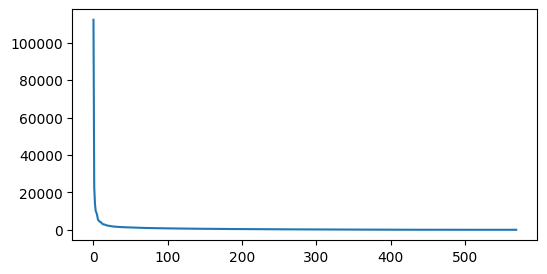

In [5]:
plt.figure(figsize=(6, 3))
plt.plot(S)
plt.show()

Use different numbers of singular vectors for reconstruction

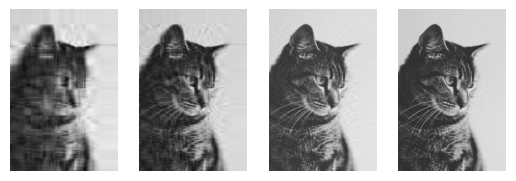

In [6]:
fig, axes = plt.subplots(nrows = 1, ncols = 4)
for i, sigma_cut_off in enumerate([10, 20, 50, 100]):
    smat = np.zeros((U.shape[0], Vh.shape[1]))
    smat[:sigma_cut_off, :sigma_cut_off] = np.diag(S[:sigma_cut_off])
    reconstructed = np.dot(U, np.dot(smat, Vh))

    axes[i].axis('off')
    axes[i].imshow(reconstructed, cmap='gray')
plt.show()

Later we will use singular vector for denoising the data \
Here we will generate a simple signal and try this methodology on it

In [7]:
def running_wave(x, shift, window):
    if x < shift or x > shift + window:
        return 0
    return m.sin(m.pi*(x-shift)/window)

signal_clean = np.zeros((1000, 100))
space_arguments = np.linspace(0, 1, signal_clean.shape[1])
for row in range(signal_clean.shape[0]):
    signal_clean[row, :] = [running_wave(x, row/1000., 0.1) for x in space_arguments]

rng = np.random.default_rng()
noise_array = rng.normal(loc=0.0, scale=0.1, size=signal_clean.shape)
signal_noised = signal_clean + noise_array

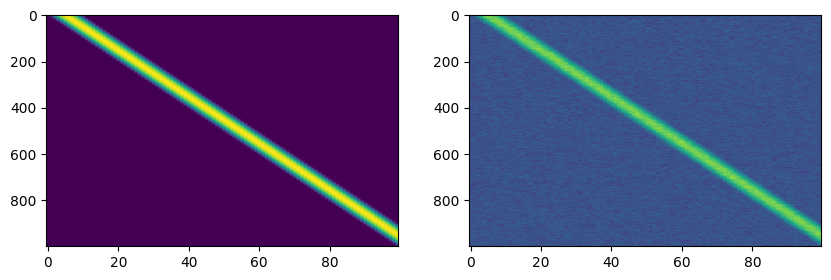

In [8]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))
axes[0].imshow(signal_clean, aspect='auto')
axes[1].imshow(signal_noised, aspect='auto')
plt.show()

Decompose the data

In [9]:
U, S, Vh = np.linalg.svd(signal_noised)
U.shape, S.shape, Vh.shape

((1000, 1000), (100,), (100, 100))

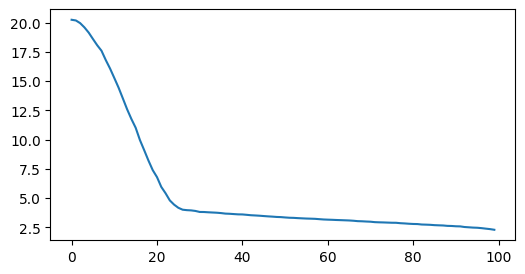

In [10]:
plt.figure(figsize=(6, 3))
plt.plot(S)
plt.show()

The elbow rule suggests we use first 24 values for reconstruction

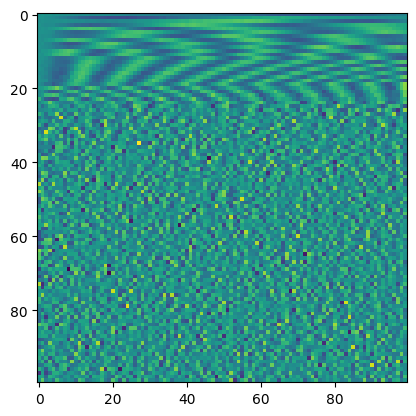

In [11]:
plt.imshow(Vh)

Indeed, the first 24 rows contain some higher harmonics, while others are mostly noise

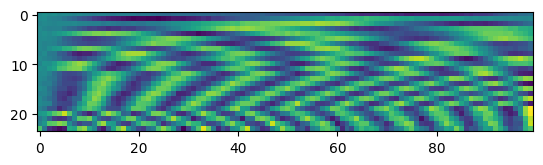

In [12]:
plt.imshow(Vh[:24, :])

In [13]:
sigma_cut_off = 24
basis = Vh[:sigma_cut_off, :].T
right_projection_matrix = basis @ np.linalg.pinv(basis)
signal_denoised = signal_noised @ right_projection_matrix

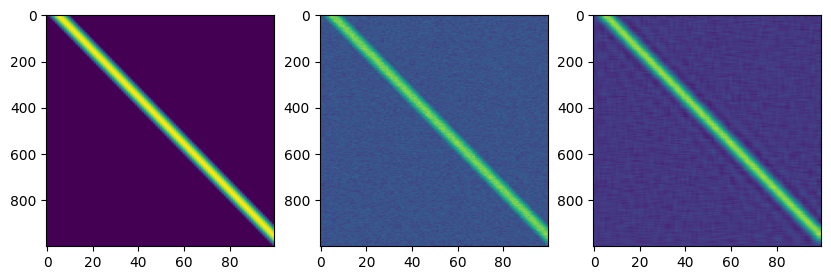

In [14]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))
axes[0].imshow(signal_clean, aspect='auto')
axes[1].imshow(signal_noised, aspect='auto')
axes[2].imshow(signal_denoised, aspect='auto')
plt.show()

Now, let's get down to real gamma-spectroscopy data \
The file contains gamma-spectroscopy data from Rwanda


In [15]:
df = pd.read_csv("assets/gr_l612.csv")
df.head()

,RAa,Sum[0],Sum[1],Sum[2],Sum[3],Sum[4],Sum[5],Sum[6],Sum[7],Sum[8],...,Sum[504],Sum[505],Sum[506],Sum[507],Sum[508],Sum[509],Sum[510],Sum[511],Xa,Ya
0,132.85,0.0,0.0,2.970486,8.052876,17.740554,35.828696,55.859256,69.460093,60.491353,...,0.0,0.0,0.990189,0.009811,0.0,0.0,0.0,145.0,2.349835e+07,7.148214e+06
1,133.17,0.0,1.0,1.485630,7.659700,23.053826,45.025059,44.575518,59.598766,81.953544,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,146.0,2.349835e+07,7.148164e+06
2,131.18,0.0,1.0,2.938114,6.532468,16.246834,43.935272,65.133266,72.010832,83.271684,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,149.0,2.349836e+07,7.148114e+06
3,129.55,0.0,0.0,2.851732,11.537556,16.155294,48.898961,53.382315,69.822596,94.442442,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,123.0,2.349837e+07,7.148063e+06
4,127.24,0.0,1.0,1.905574,4.600700,21.225192,29.950148,55.515628,70.454690,69.559092,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,144.0,2.349837e+07,7.148014e+06


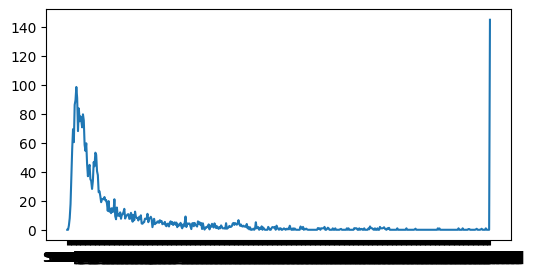

In [16]:
plt.figure(figsize=(6, 3))
plt.plot(df.iloc[0, 1:-2])
plt.show()

In [17]:
data_matrix = np.array(df.iloc[:, 1:-2])
data_matrix.shape

(150, 512)

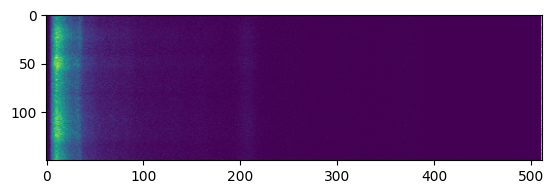

In [18]:
plt.imshow(data_matrix)

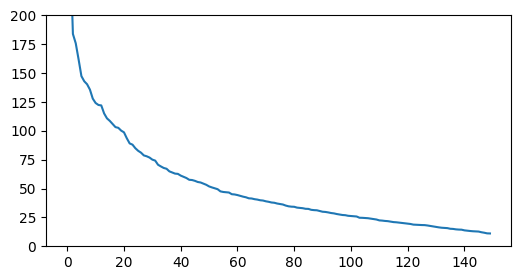

In [19]:
U, S, Vh = np.linalg.svd(data_matrix)
plt.figure(figsize=(6, 3))
plt.ylim(0, 200)
plt.plot(S)
plt.show()

The main signal energy is contained in first 20-40 modes

In [20]:
sigma_cut_off = 10
basis = Vh[:sigma_cut_off, :].T
right_projection_matrix = basis @ np.linalg.pinv(basis)
data_smoothed = data_matrix @ right_projection_matrix

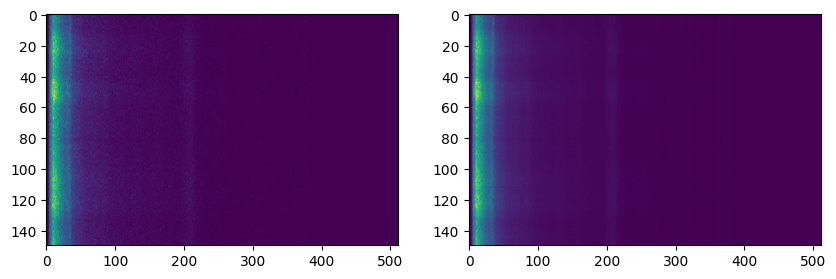

In [21]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))
axes[0].imshow(data_matrix, aspect='auto')
axes[1].imshow(data_smoothed, aspect='auto')
plt.show()

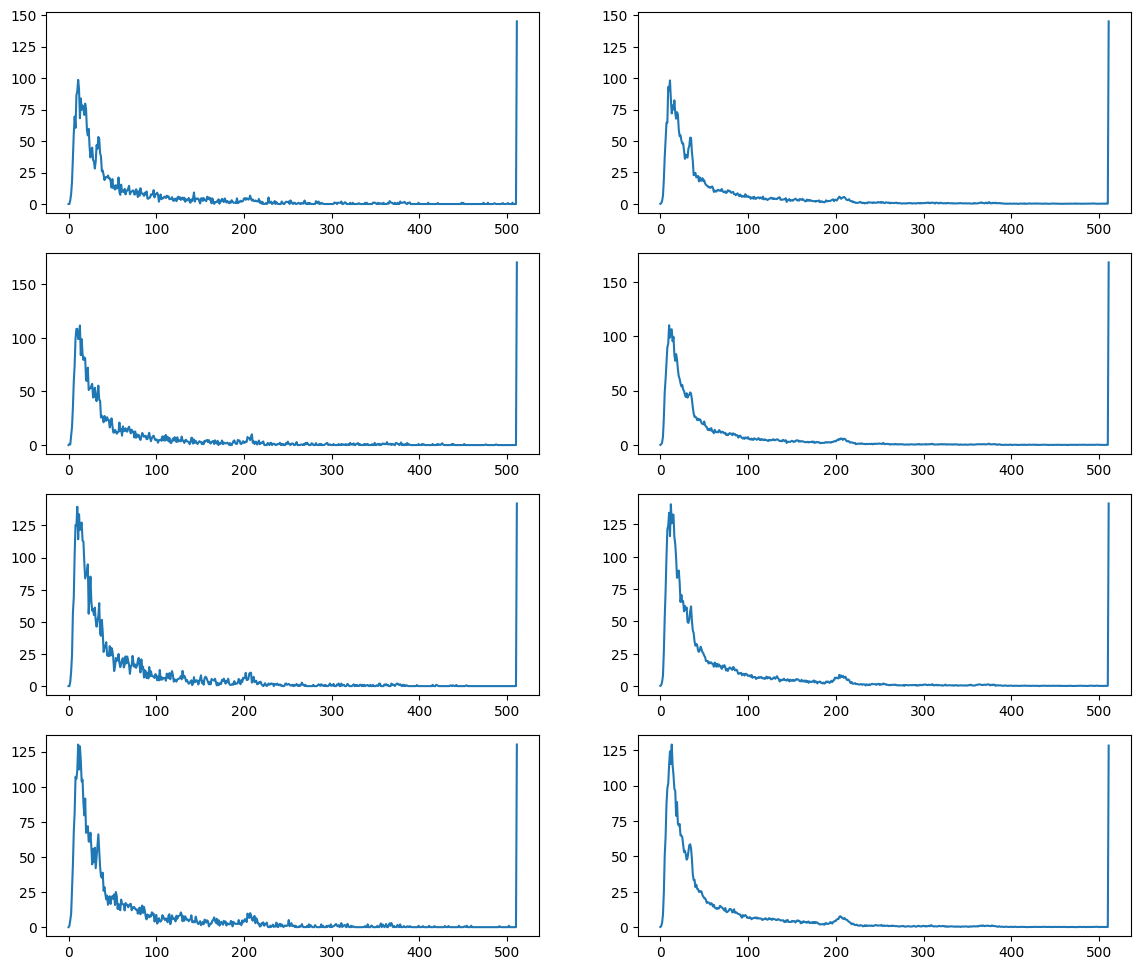

In [22]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 12))
for row, sample_number in enumerate([0, 10, 20, 30]):
    axes[row, 0].plot(data_matrix[sample_number, :])
    axes[row, 1].plot(data_smoothed[sample_number, :])
plt.show()

The data are denoised, but not as much as we might want \
Let's use more

In [25]:
df = pd.read_csv("assets/gr_all_lines.csv")
df.head()

,RAa,Sum[0],Sum[1],Sum[2],Sum[3],Sum[4],Sum[5],Sum[6],Sum[7],Sum[8],...,Sum[504],Sum[505],Sum[506],Sum[507],Sum[508],Sum[509],Sum[510],Sum[511],Xa,Ya
0,132.85,0.0,0.0,2.970486,8.052876,17.740554,35.828696,55.859256,69.460093,60.491353,...,0.0,0.0,0.990189,0.009811,0.0,0.0,0.0,145.0,2.349835e+07,7.148214e+06
1,133.17,0.0,1.0,1.485630,7.659700,23.053826,45.025059,44.575518,59.598766,81.953544,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,146.0,2.349835e+07,7.148164e+06
2,131.18,0.0,1.0,2.938114,6.532468,16.246834,43.935272,65.133266,72.010832,83.271684,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,149.0,2.349836e+07,7.148114e+06
3,129.55,0.0,0.0,2.851732,11.537556,16.155294,48.898961,53.382315,69.822596,94.442442,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,123.0,2.349837e+07,7.148063e+06
4,127.24,0.0,1.0,1.905574,4.600700,21.225192,29.950148,55.515628,70.454690,69.559092,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,144.0,2.349837e+07,7.148014e+06


In [55]:
data_matrix = np.array(df.iloc[:, 1:-2])
data_matrix.shape

(1744, 512)

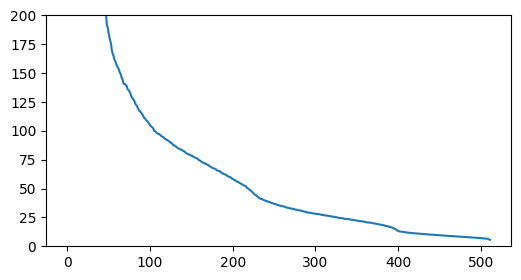

In [38]:
U, S, Vh = np.linalg.svd(data_matrix)
plt.figure(figsize=(6, 3))
plt.ylim(0, 200)
plt.plot(S)
plt.show()

In [46]:
sigma_cut_off = 10
basis = Vh[:sigma_cut_off, :].T
right_projection_matrix = basis @ np.linalg.pinv(basis)
data_smoothed = data_matrix @ right_projection_matrix

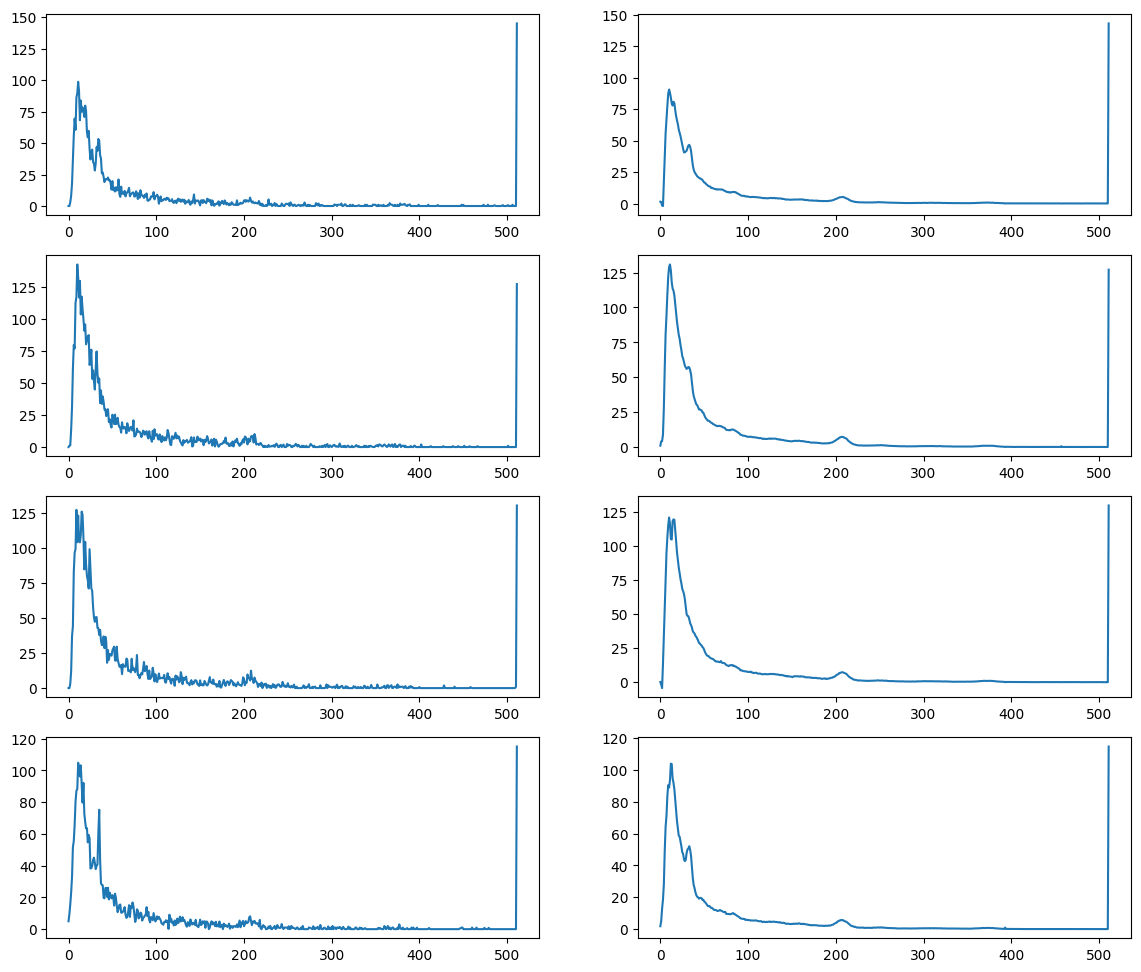

In [47]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 12))
for row, sample_number in enumerate([0, 100, 500, 1500]):
    axes[row, 0].plot(data_matrix[sample_number, :])
    axes[row, 1].plot(data_smoothed[sample_number, :])
plt.show()

As we see, SVD smoothes well, but smaller spectral peakc remain small. \
Let's display the singular vectors

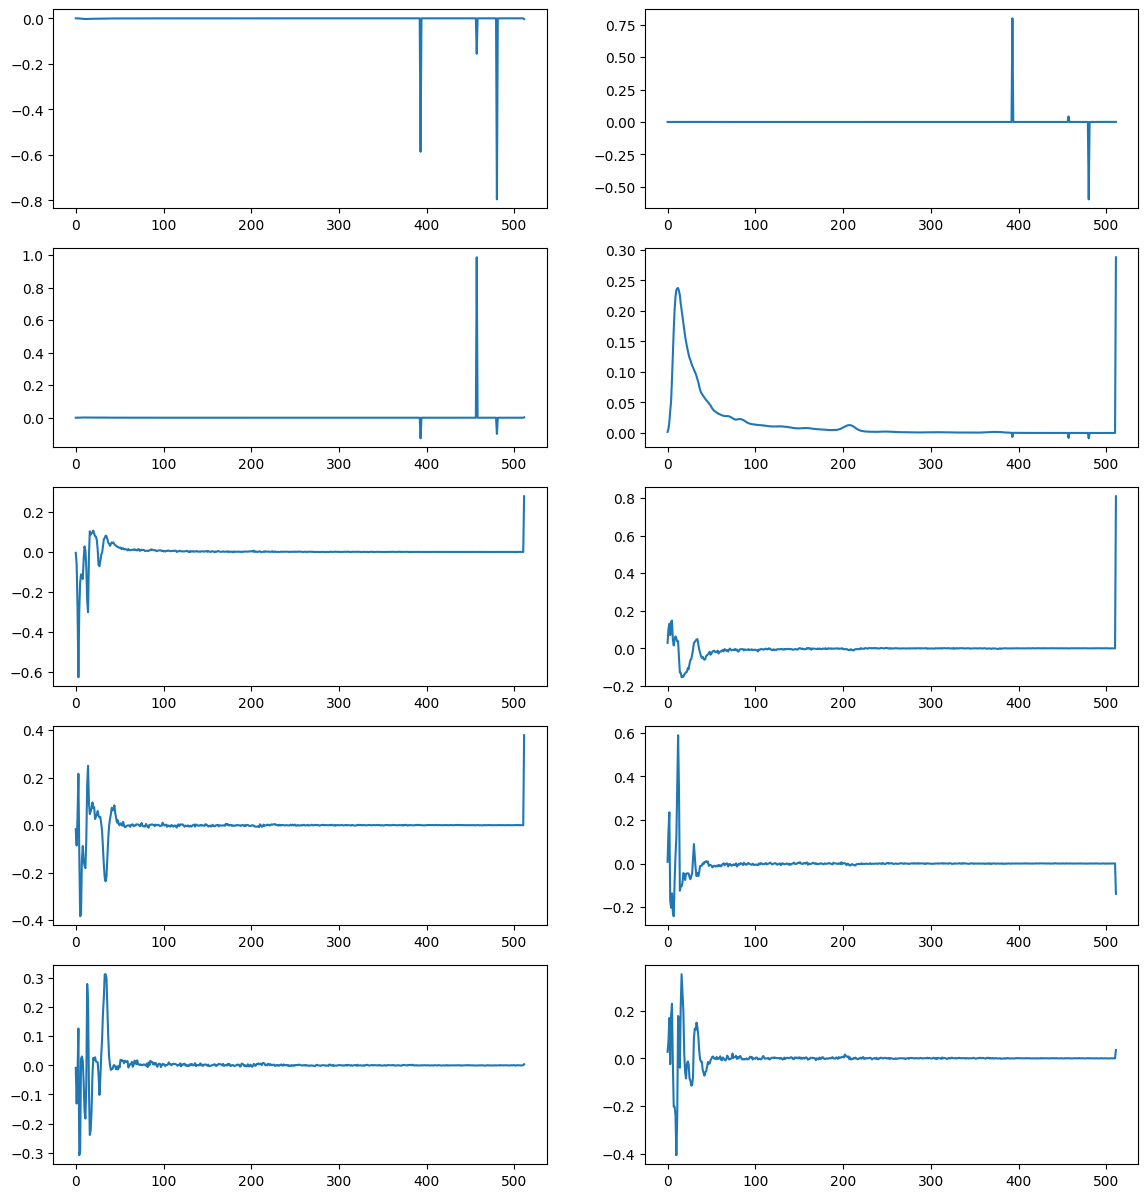

In [48]:
fig, axes = plt.subplots(nrows=sigma_cut_off//2, ncols=2, figsize=(14, 3*sigma_cut_off//2))
for spec_vec_num in range(sigma_cut_off):
    axes[spec_vec_num//2, spec_vec_num%2].plot(Vh[spec_vec_num, :])
plt.show()

Aha, there is clearly a problem with the right part - cosmic rays of high energy. \
Let's remove it

In [56]:
data_matrix = np.array(df.iloc[:, 1:-3])

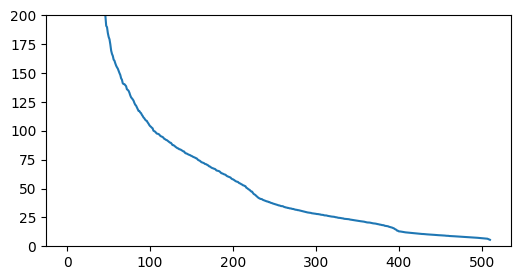

In [57]:
U, S, Vh = np.linalg.svd(data_matrix)
plt.figure(figsize=(6, 3))
plt.ylim(0, 200)
plt.plot(S)
plt.show()

In [58]:
sigma_cut_off = 10
basis = Vh[:sigma_cut_off, :].T
right_projection_matrix = basis @ np.linalg.pinv(basis)
data_smoothed = data_matrix @ right_projection_matrix

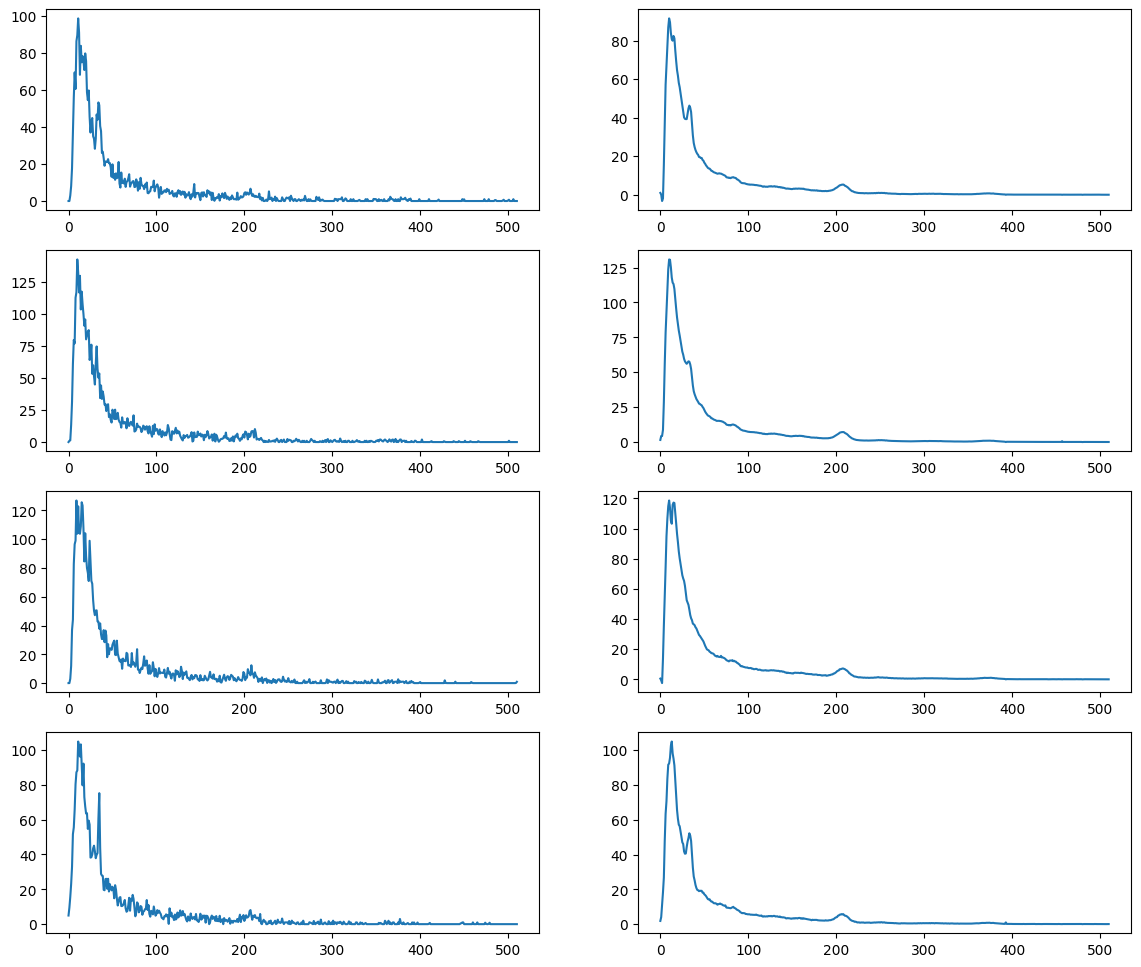

In [59]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 12))
for row, sample_number in enumerate([0, 100, 500, 1500]):
    axes[row, 0].plot(data_matrix[sample_number, :])
    axes[row, 1].plot(data_smoothed[sample_number, :])
plt.show()

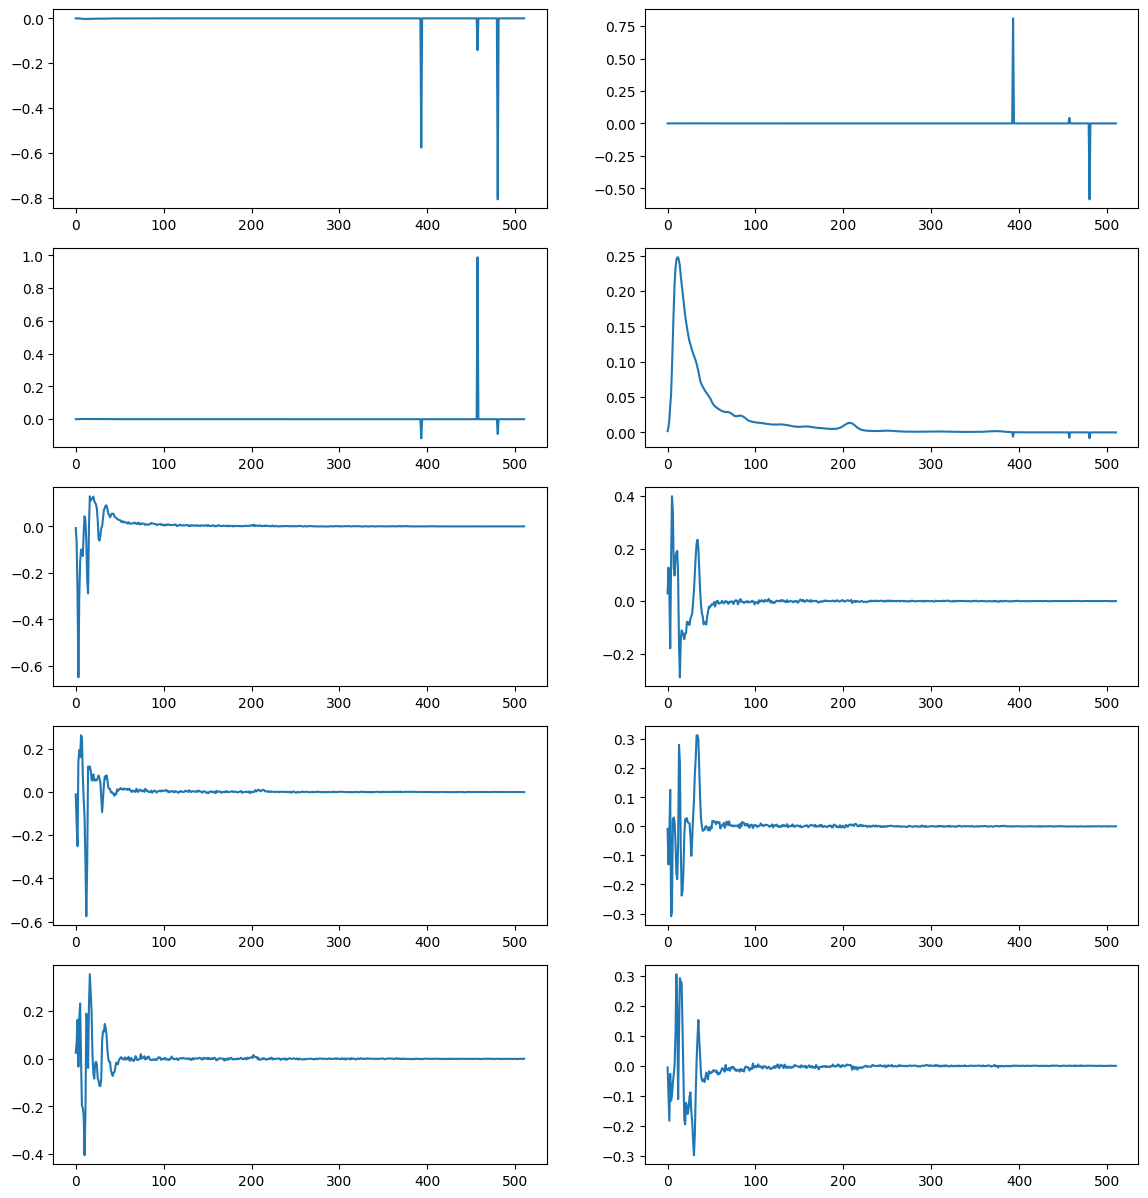

In [60]:
fig, axes = plt.subplots(nrows=sigma_cut_off//2, ncols=2, figsize=(14, 3*sigma_cut_off//2))
for spec_vec_num in range(sigma_cut_off):
    axes[spec_vec_num//2, spec_vec_num%2].plot(Vh[spec_vec_num, :])
plt.show()

The first three spectral components probably come from Thorium, but are much affected with noise \
Let's remove them and use only higher components for smoothing

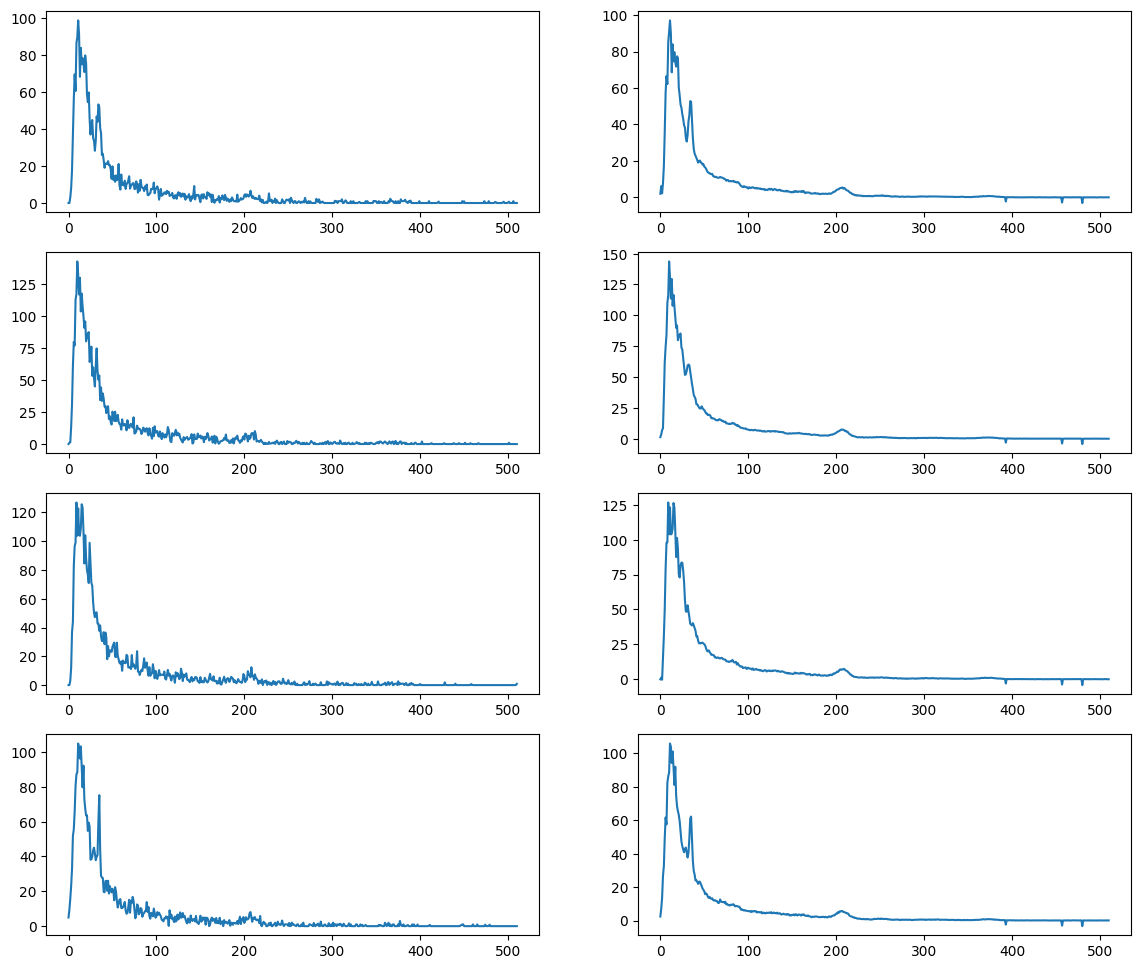

In [62]:
lower_cut_off = 3
upper_cut_off = 25
basis = Vh[lower_cut_off:upper_cut_off, :].T
right_projection_matrix = basis @ np.linalg.pinv(basis)
data_smoothed = data_matrix @ right_projection_matrix

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 12))
for row, sample_number in enumerate([0, 100, 500, 1500]):
    axes[row, 0].plot(data_matrix[sample_number, :])
    axes[row, 1].plot(data_smoothed[sample_number, :])
plt.show()